# **Petike and the Parametric Palette**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>AI National Olympiad Qualifier</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Computer Vision</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 points</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>May 24, 2025</span>
  </div>
</div>

**Name:** [WRITE YOUR NAME HERE]

**Contestant ID:** [WRITE YOUR CONTESTANT ID HERE]

<img src="https://drive.google.com/uc?export=view&id=1zqzy6u66LW5HzD6gEpZRpXO1Mpi8KG_z" alt="petike" style="width:150px;">

Petike is a little kid in preschool. His favorite activity is drawing. He recently got to know the basic shapes (**circle, square, and triangle**), and he is very enthusiastic about making drawings from them.

However, the teaching period has now ended. Petike no longer learns from new examples; he only knows what he learned from his previous drawings. If we want something from him now, **we can only ask him through his latent space**.

In this task, your goal is to find points in the latent space that will make Petike draw nice and varied pictures.

Petike is a little kid in preschool. His favorite activity is drawing. He recently got to know the basic shapes (**circle, square, and triangle**), and he is very enthusiastic about making drawings from them. However, in kindergarten there are only few crayon colors, so Petike has only used **red, blue, and green** so far. He gives every finished drawing to the teacher, who helps him draw more and more beautifully.

But the teacher is a strange being: she doesn’t say a word, yet she always knows exactly how well the drawing turned out, and Petike feels it too. In reality, the teacher is nothing less than a **loss function**, who silently but firmly gives Petike feedback after each drawing about how clever he was. This is how Petike learned to draw shapes during teaching.

However, the teaching period has now ended. Petike no longer learns from new examples; he only knows what he learned from his previous drawings. But we can still communicate with him, just not as with an ordinary preschooler.

Petike cannot be directly instructed, nor does he understand new examples. There is only one way we can understand each other: **through his latent space**. If we give him a point there, Petike transforms it into a drawing in his own style.

<ins>Fortunately, we have a few tools at our disposal</ins>:

- **Petike’s decoder**: from this we know what he will draw based on a given latent point;

- **Petike’s encoder**: with this we can map existing drawings into the latent space, so for example if we show him an example (e.g., a red square), we can find out where Petike „imagines” it in the latent space;

- **Petike’s external classifiers**: besides drawing what he imagines in the latent space, he can also point out what he intended to draw.

<ins>**The task:**</ins>

Explain to Petike through the latent space to draw:

- **5 different magenta circles**
- **5 different orange triangles**
- **5 different images where the color blue appears**

## **Useful links**

- [What is a variational autoencoder?](https://www.ibm.com/think/topics/variational-autoencoder)
- [PyTorch](https://docs.pytorch.org/docs/stable/index.html)
- [Pillow](https://pillow.readthedocs.io/en/stable/)
- [numpy](https://numpy.org/doc/stable/)
- [matplotlib](https://matplotlib.org/stable/users/index.html)

## **Required Imports**

We have imported some libraries to get started, but feel free to use any PyTorch-based tools if needed. Please note that Keras and TensorFlow are **NOT ALLOWED** for solving this task!

In [1]:
!pip install --q torchview

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
from torchview import draw_graph
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Petike’s architecture**

**Help**: Petike thinks like a Variational Autoencoder.

A **variational autoencoder (VAE)** is an artificial neural network used for generating images (or other data). The essence is that it learns how to represent an image in a simpler, compact form (in the latent space), and then reconstruct the image from this internal representation.

The VAE:
- consists of an **encoder** (which jumps from the image to the latent space),
- a **decoder** (which generates an image from the latent space),
- and a **special training method** where we learn probability distributions instead of a single point.

This allows the model to have „imagination”: it can create new images it has never seen, yet they fit the learned patterns.

In [2]:
LATENT_DIM = 3
LATENT_FEATURE_SIZE = LATENT_DIM * 4 * 4

class Petike(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, device=None):
        super(Petike, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(128 * 4 * 4, LATENT_FEATURE_SIZE)
        self.fc_logvar = nn.Linear(128 * 4 * 4, LATENT_FEATURE_SIZE)

        self.decoder_input = nn.Linear(LATENT_FEATURE_SIZE, LATENT_FEATURE_SIZE)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (latent_dim, 4, 4)),
            nn.ConvTranspose2d(latent_dim, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

        self.register_buffer("shape_input", torch.zeros(LATENT_FEATURE_SIZE))
        self.shape_input[0:24] = 1.0

        self.register_buffer("color_input", torch.zeros(LATENT_FEATURE_SIZE))
        self.color_input[24:48] = 1.0

        for i in [0, 12, 24, 36]:
            self.color_input[i] = 0.0
            self.shape_input[i] = 0.0

        self.shape_classifier = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        self.color_classifier = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        self.size_regressor = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

        self.mask_head = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 48),
            nn.ReLU(),
            nn.Linear(48, 32 * 32),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


    def decode(self, z):
        x = self.decoder_input(z)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        shape_logits = self.shape_classifier(z * self.shape_input)
        color_logits = self.color_classifier(z * self.color_input)
        size_pred = self.size_regressor(z).squeeze(1)
        mask_pred = self.mask_head(z).view(-1, 1, 32, 32)
        return recon, mu, logvar, shape_logits, color_logits, size_pred, mask_pred

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def l1_latent_regularization(self):
        l1 = 0.
        for layer in [self.fc_mu, self.decoder_input]:
            for param in layer.parameters():
                l1 += param.abs().sum()
        return l1

    def l1_classifier_regularization(self):
        l1 = 0.
        for classifier in [self.shape_classifier, self.color_classifier, self.size_regressor]:
            for param in classifier.parameters():
                l1 += param.abs().sum()
        return l1

## **Some examples of Petike’s drawings**

## **Download Petike**

In the next step, we download Petike’s model so we can experiment with the latent space. This model is already pre-trained, so it can be immediately used for image generation, encoding, and classification.

## **Initialize Petike**


(process:3180): Pango-WARNING **: 18:00:11.445: couldn't load font "Linux libertine Not-Rotated 10", falling back to "Sans Not-Rotated 10", expect ugly output.


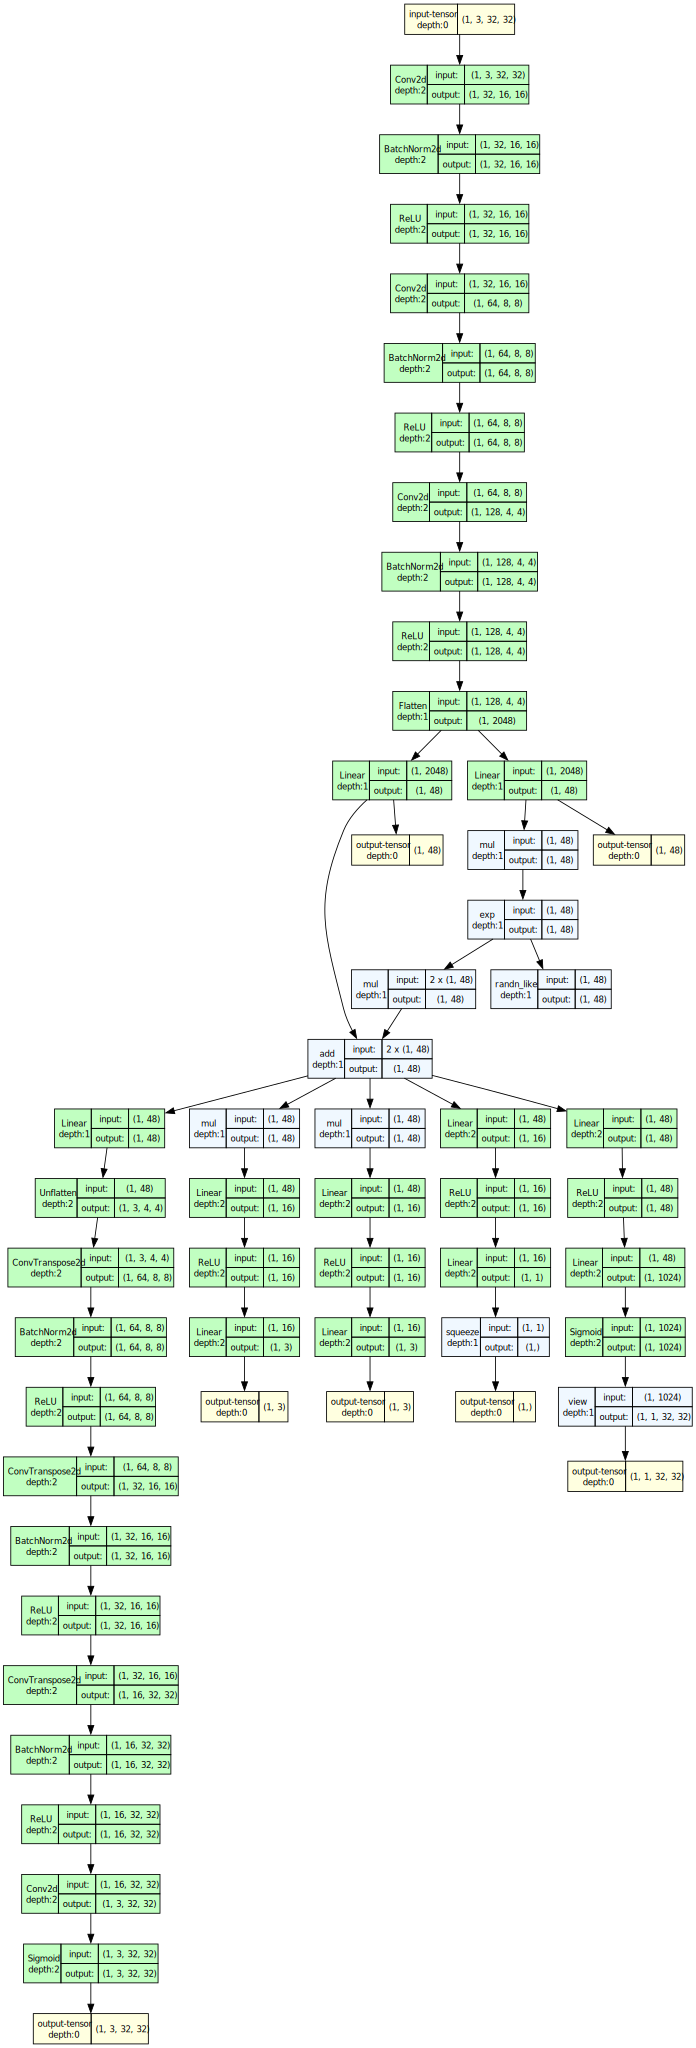

In [3]:
petike = Petike().to(device)
petike.load_state_dict(torch.load("./data_palette4/petike.pth", map_location=torch.device(device)))

model_graph = draw_graph(petike, input_size=(1,3,32,32), expand_nested=False)
model_graph.visual_graph

# **Task 1 - Helper Functions (25 points)**

You have been given the following functions to use Petike’s generative model. They help you transform images into latent representations and back, as well as generate new images using only the latent space.

---

### `image_to_tensor(img)`

This function converts a `PIL.Image` into a PyTorch tensor that the model can understand. That means:
- it transforms the image into a `[C, H, W]` array (channels, height, width),
- normalizes the values between 0 and 1,
- adds a batch dimension, making it `[1, C, H, W]`.

---

### `tensor_to_image(tensor)`

With this function you can turn a PyTorch tensor back into an image (`PIL.Image` format) that you can display. This is the reverse of the previous step.

---

### `draw_shape(shape, size, position, color)`

This function draws a shape on a **32x32 pixel canvas**:
- `shape`: can be `'circle'`, `'square'`, or `'triangle'`
- `size`: size of the shape in pixels
- `position`: top-left corner `(x, y)` coordinates
- `color`: color, e.g., `'red'`, `'blue'`, or `(255, 165, 0)` (RGB)

This can be useful for creating example images or testing!

---

### `reconstruct(model, batch)`

With this function you can reconstruct an input image using the model. The model first encodes the image into the latent space, then decodes it back into an image. This way you can check how well Petike „remembers” the given image.

---

### `encode(model, batch)`

This function encodes your images into the **latent space**. The output is a vector that compactly describes what Petike thinks is in the image. These vectors can be used to **manipulate** or generate new images.

---

### `decode(model, latent_vector)`

This is the opposite of the previous one: it generates a **new image** from a latent vector. This is how you „ask” Petike to draw something. If you choose the latent points well, he will make nice and varied pictures!

## **Implement the following helper functions that will help you solve the task.**

In [16]:
def image_to_tensor(img):
    """
    Convert a PIL image to a tensor and normalize it.
    Args:
        img (PIL.Image): Input image.
    Returns:
        torch.Tensor: Normalized tensor representation of the image with shape (B, C, H, W).
    """
    # --------- YOUR SOLUTION GOES HERE --------- (~2-3 lines)
    arr = np.array(img) / 255.0
    return torch.tensor(arr).float().permute(2,0,1).unsqueeze(0)
    # ----------- END OF YOUR SOLUTION -------------


def tensor_to_image(tensor):
    """
    Convert a tensor to a PIL image.
    Args:
        tensor (torch.Tensor): Input tensor with shape (B, C, H, W).
    Returns:
        PIL.Image: Image representation of the tensor.
    """
    # --------- YOUR SOLUTION GOES HERE --------- (~2-3 lines)
    tensor = tensor.squeeze(0).permute(1,2,0)
    arr = (tensor.detach().cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
    return Image.fromarray(arr)
    # ----------- END OF YOUR SOLUTION -------------


def draw_shape(shape, size, position, color):
    """
    Draw a shape on a blank image with size 32x32.
    Args:
        draw (PIL.ImageDraw): ImageDraw object to draw on.
        shape (str): Shape type ('triangle', 'square', 'circle').
        size (int): Size of the shape.
        position (tuple): Position (x, y) to draw the shape.
        color (tuple): Color of the shape (R, G, B) or string literals like ('red', 'blue', 'green').
    """
    # --------- YOUR SOLUTION GOES HERE --------- (~12-14 lines)
    image = Image.new("RGB", (32, 32), (255, 255, 255))
    draw = ImageDraw.Draw(image)
    x, y = position
    if shape == "triangle":
        points = [
            (x + size // 2, y),  # top
            (x, y + size),       # bottom left
            (x + size, y + size) # bottom right
        ]
        draw.polygon(points, fill=color)
    elif shape == "square":
        draw.rectangle([x, y, x + size, y + size], fill=color)
    elif shape == "circle":
        draw.ellipse([x, y, x + size, y + size], fill=color)

    return image
    # ----------- END OF YOUR SOLUTION -------------


def reconstruct(model, batch):
    """
    Reconstruct the input batch using the loaded model.
    Args:
        batch (torch.Tensor): Input batch of images.
    Returns:
        torch.Tensor: Reconstructed images.
    """
    # --------- YOUR SOLUTION GOES HERE --------- (~5-6 lines)
    model.eval()
    with torch.no_grad():
        latent_vector = model.encode(batch)
        latent_vector = latent_vector[0].unsqueeze(0)
        recon = model.decode(latent_vector[0])

    return recon
    # ----------- END OF YOUR SOLUTION -------------


def encode(model, batch):
    """
    Encode the input batch using the loaded model.
    Args:
        batch (torch.Tensor): Input batch of images with shape (B, C, H, W).
    Returns:
        torch.Tensor: Encoded latent vectors.
    """
    # --------- YOUR SOLUTION GOES HERE --------- (~5-6 lines)
    model.eval()
    with torch.no_grad():
        latent_vector = model.encode(batch)
        latent_vector = latent_vector[0].unsqueeze(0)

    return latent_vector
    # ----------- END OF YOUR SOLUTION -------------


def decode(model, latent_vector):
    """
    Decode the latent vector using the loaded model.
    Args:
        latent_vector (torch.Tensor): Latent vector to decode with shape (B, 48).
    Returns:
        torch.Tensor: Reconstructed images.
    """
    # --------- YOUR SOLUTION GOES HERE --------- (~4-5 lines)
    model.eval()
    with torch.no_grad():
        recon = model.decode(latent_vector[0])

    return recon
    # ----------- END OF YOUR SOLUTION -------------

In [ ]:
# --------- YOUR SOLUTION GOES HERE --------- (~20-30 lines)

# ----------- END OF YOUR SOLUTION -------------

# **Task 2 (25 points)**

Now we ask Petike to draw a magenta circle.

To do this, first create an example image with such a circle, then encode it into the latent space. Based on the latent representation, Petike will try to reproduce what he understood from it.

Observe how well he manages to retain the circle and the magenta color in the reconstruction. Feel free to experiment with circles of different sizes or positions.

Partial points can be awarded if fewer correct images are displayed!

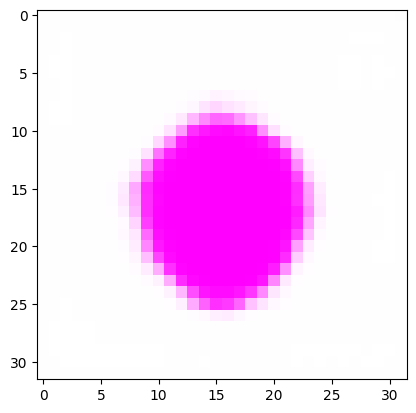

In [38]:
img = draw_shape('circle', 20, (4,4), (255, 0, 255))
tensor = image_to_tensor(img).to(device)
outs = reconstruct(petike, tensor)
new_img = tensor_to_image(outs)
plt.imshow(new_img)

# **Task 3 (25 points)**

In this task we ask Petike to draw an orange triangle.

First draw an example image, then transform it into a form Petike understands. This can be encoded into the latent space, then decoded to ask him again to draw it.

The goal is to see how well Petike can reproduce the essence of the shape and color. It is worth experimenting with different sizes and positions as well.

Partial points can be awarded if fewer correct images are displayed!

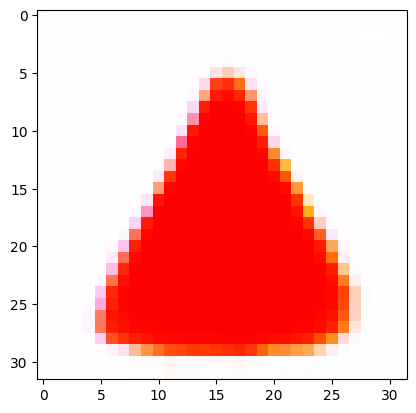

In [50]:
# --------- YOUR SOLUTION GOES HERE --------- (~20-30 lines)
img = draw_shape('triangle', 32, (5,5), (120, 0, 0))
tensor = image_to_tensor(img).to(device)
outs = reconstruct(petike, tensor)
new_img = tensor_to_image(outs)
plt.imshow(new_img)
# ----------- END OF YOUR SOLUTION -------------

# **Task 4 (25 points)**

In this task, the goal is for Petike to draw an image where the color blue appears at least minimally.

Petike rarely uses blue, so he might not choose it willingly. We can help him by showing an example image with a blue shape, thus reinforcing its importance in the latent space.

It is worth experimenting with various blue shapes and observing to what extent Petike can reproduce this in his drawings.

Partial points can be awarded if fewer correct images are displayed!

In [ ]:
def prompt(shape, size, xy, color):
    img = draw_shape(shape, size, xy, color)
    tensor = image_to_tensor(img).to(device)
    outs = reconstruct(petike, tensor)
    new_img = tensor_to_image(outs)
    return new_img

# fig, ax = plt.subplots(nrows=3, ncols=5)
# ax = ax.flatten()
# for i, size in enumerate(range(10, 32, 2)):
#     ax[i].axis('off')
#     ax[i].imshow(prompt('triangle', size, (0,0)))
#     ax[i].set_title(f'Size: {size}')

# fig, ax = plt.subplots(nrows=40, ncols=20)
# ax = ax.flatten()
# fig.set_size_inches(10,10)
# i = 0
# for green in range(0, 255, 25):
#     for red in range(0, 255, 25):
#         ax[i].axis('off')
#         ax[i].imshow(prompt('square', 30, (0,0), (red, green, 255)))
#         i+=1
#         # ax[i].set_title(f'Size: {size}')

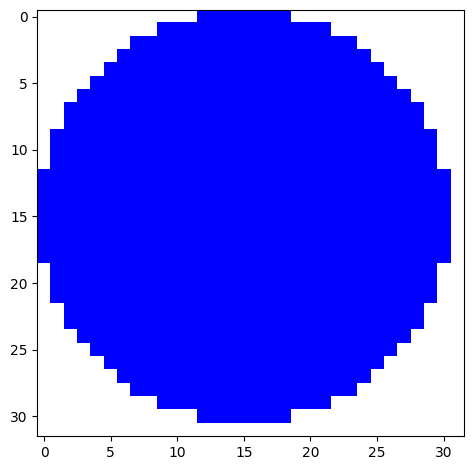

In [108]:
num_samples = 20
images_per_row = 3 
rows = num_samples

# Random green triangle
green_triangle = draw_shape("circle", 30, (0,0), "blue")
green_tensor = image_to_tensor(green_triangle).to(device)
z_green = encode(petike, green_tensor)

plt.imshow(green_triangle)
plt.tight_layout()
plt.show()

---

## 🎉 Congratulations!

You have reached the end of the task set - excellent work!  

---